# Chapter 09 텍스트를 위한 인공 신경망
## 09-3 LSTM과 GRU 셀
* 이 절에서는 고급 순환층인 LSTM과 GRU에 대해 알아보겠음. 이런 층들은 2절에서 배웠던 SimpleRNN보다 계산이 훨씬 복잡. 하지만 성능이 뛰어나기 때문에 순환 신경망에 많이 채택되고 있음.
* 일반적으로 기본 순환층은 긴 시퀀스를 학습하기 어려움. 시퀀스가 길수록 순환되는 은닉 상태에 담긴 정보가 점차 희석되기 때문. 따라서 멀리 떨어져 있는 단어 정보를 인식하는 데 어려울 수 있음. 이를 위해 LSTM과 GRU 셀이 발명되었음.

### LSTM 구조
* LSTM은 Long Short-Term Memory의 약자. 말 그대로 단기 기억을 오래 기억하기 위해 고안되었음. LSTM은 구조가 복잡하므로 단계적으로 설명하겠음. 하지만 기본 개념은 동일. LSTM에는 입력과 가중치를 곱하고 절편을 더해 활성화 함수를 통과시키는 구조를 여러 개 가지고 있음. 이런 계산 결과는 다음 타입스텝에 재사용됨.
* 먼저 은닉 상태를 만드는 방법. 은닉 상태는 입력과 이전 타임스텝의 은닉 상태를 가중치에 곱한 후 활성화 함수를 통과시켜 다음 은닉 상태를 만듦. 이때 기본 순환층과는 달리 시그모이드 활성화 함수를 통과시켜 다음 은닉 상태를 만듦. 이때 기본 순환층과는 달리 시그모이드 활성화 함수를 사용. 또 tanh 활성화 함수를 통과한 어떤 값과 곱해져서 은닉 상태를 만듦.
* LSTM에는 순환되는 상태가 2개. 은닉 상태 말고 **셀 상태cell state**라고 부르는 값이 또 있음. 은닉 상태와 달리 셀 상태는 다음 층으로 전달되지 않고 LSTM 셀에서 순환만 되는 값.
* 셀 상태를 계산하는 과정은 다음과 같음. 먼저 입력과 은닉 상태를 또 다른 가중치 $w_{f}$에 곱한 다음 시그모이드 함수를 통과시킴. 그다음 이전 타임스텝의 셀 상태와 곱하여 새로운 셀 상태를 만듦. 이 셀 상태가 오른쪽에서 tahn 함수를 통과하여 새로운 은닉 상태를 만드는 데 기여.
* 중요한 것은 입력과 은닉 상태에 곱해지는 가중치 $w_{o}$와 $w_{f}$가 다르다는 점. 이 두 작은 셀은 각기 다른 기능을 위해 훈련됨. 그런데 LSTM 셀은 이게 끝이 아님!
* 여기에 2개의 작은 셀이 더 추가되어 셀 상태를 만드는 데 기여.
* 이전과 마찬가지로 입력과 은닉 상태를 각기 다른 가중치에 곱한 다음, 하나는 시그모이드 함수를 통과시키고 다른 하나는 tanh 함수를 통과시킴. 그다음 두 결과를 곱한 후 이전 셀 상태와 더함. 이 결과가 최종적인 셀 상태.
* 세 군데의 곱셈을 왼쪽부터 차례대로 삭제 게이트, 입력 게이트, 출력 게이트라고 부름.
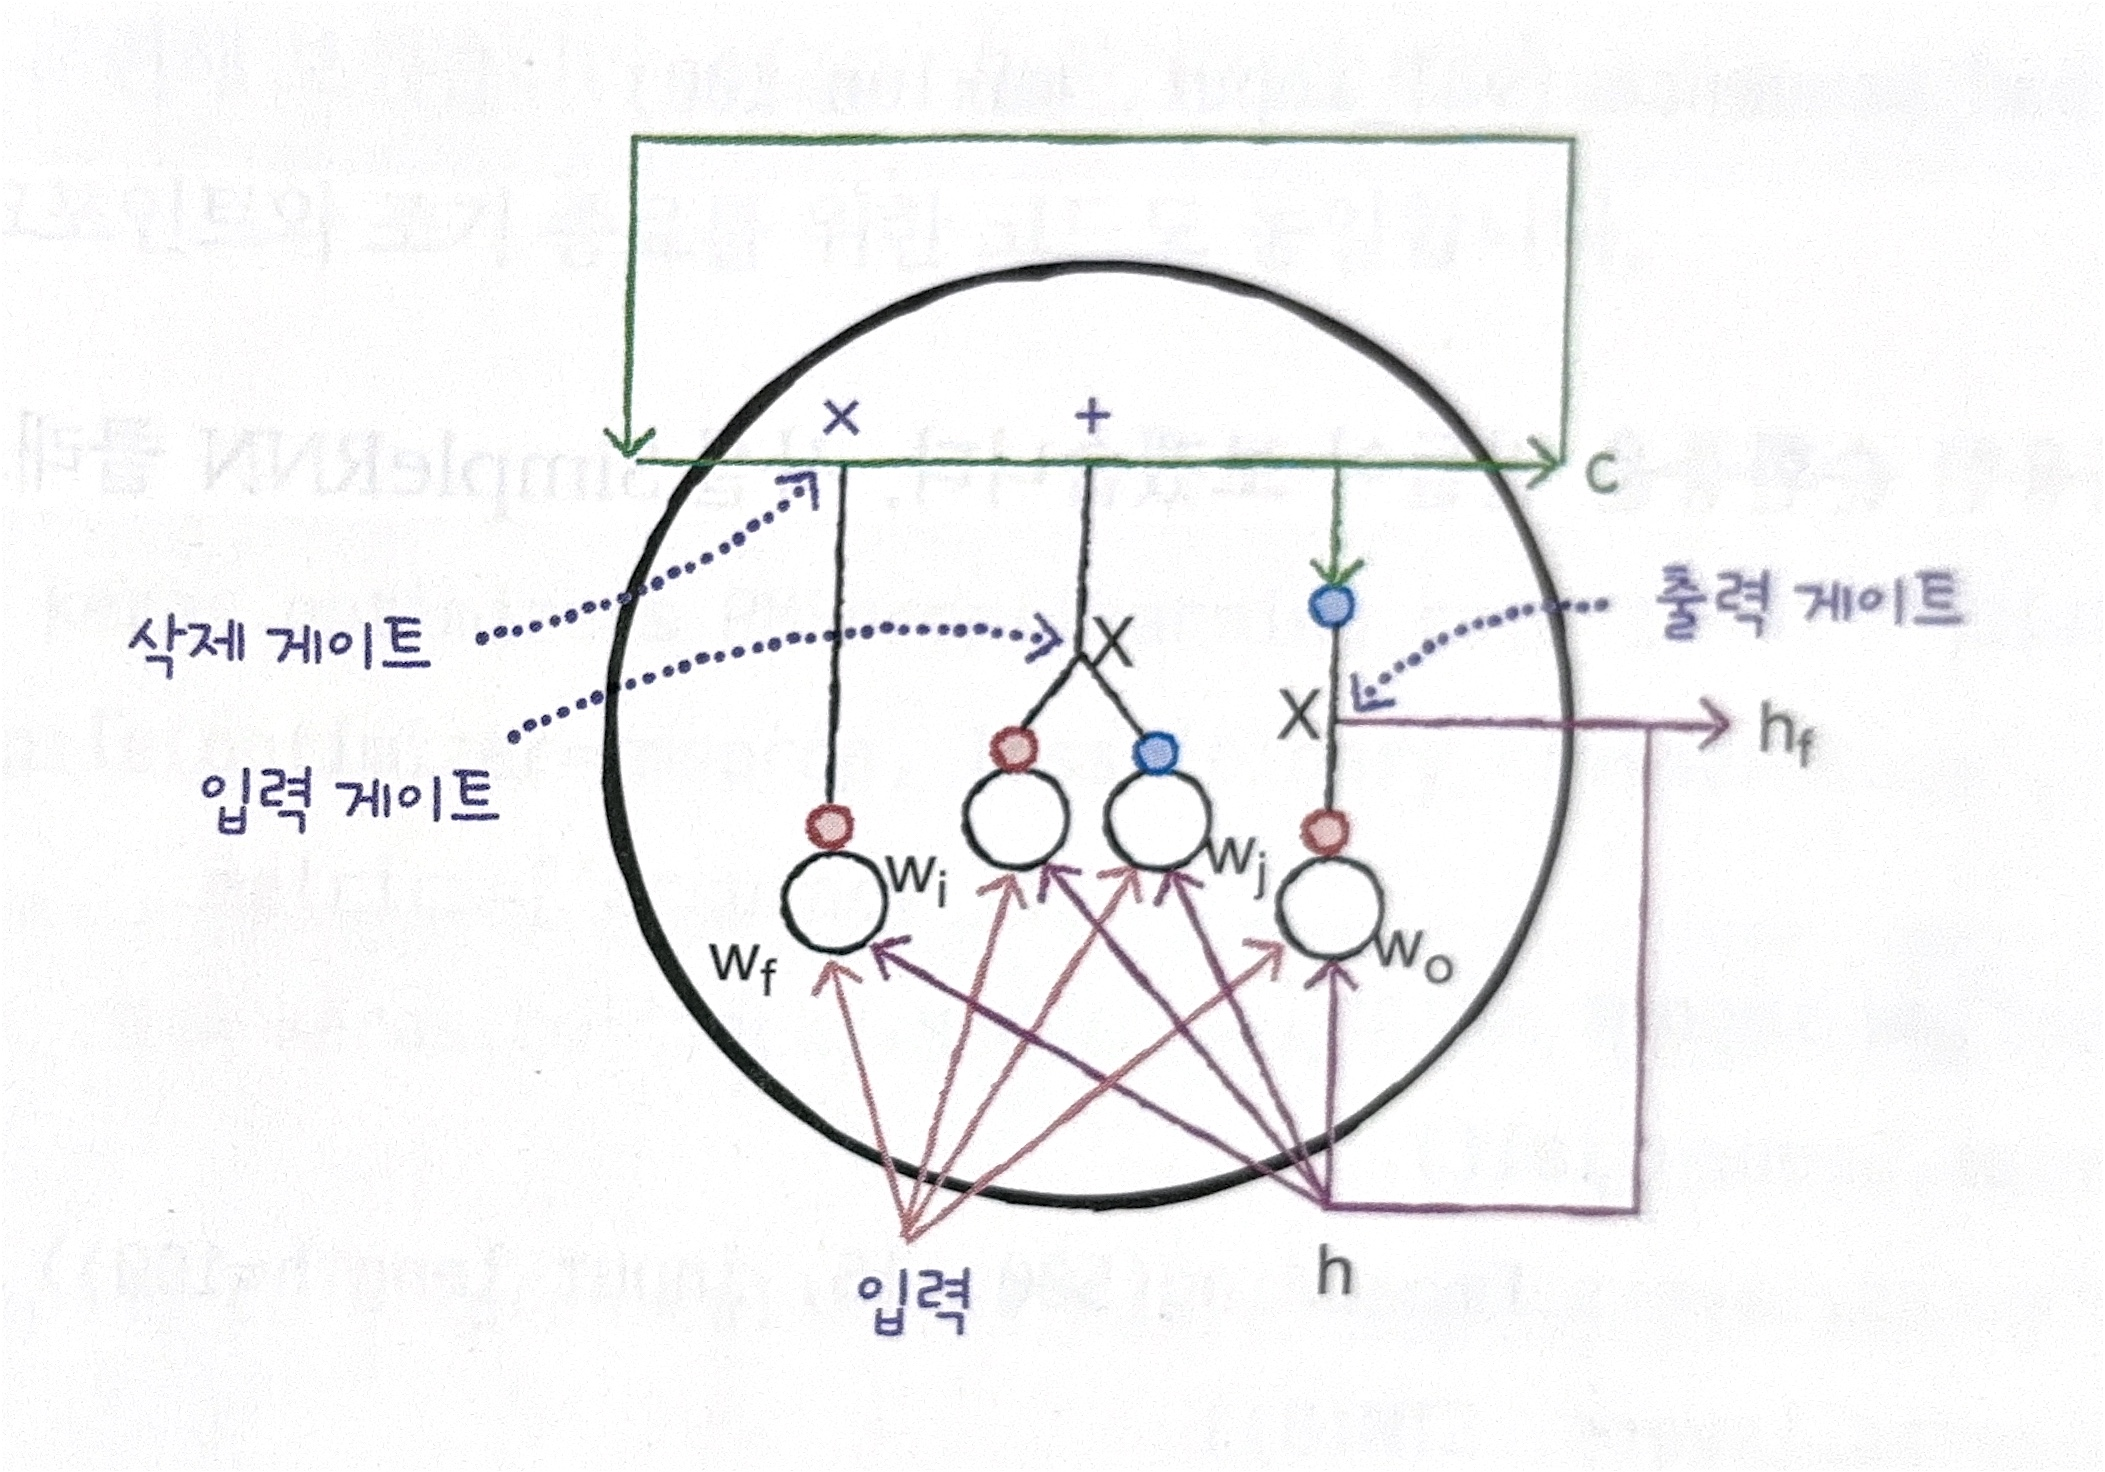
* 삭제 게이트는 셀 상태에 있는 정보를 제거하는 역할을 하고 입력 게이트는 새로운 정보를 셀 상태에 추가. 출력 게이트를 통해서 이 셀 상태가 다음 은닉 상태로 출력됨.

### LSTM 신경망 훈련하기

In [1]:
from tensorflow.keras.datasets import imdb
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [3]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.Embedding(500, 16, input_length=100))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4996 - loss: 0.6931

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.5197 - loss: 0.6929 - val_accuracy: 0.5522 - val_loss: 0.6924
Epoch 2/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5730 - loss: 0.6921

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.5822 - loss: 0.6917 - val_accuracy: 0.6024 - val_loss: 0.6908
Epoch 3/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6084 - loss: 0.6899

313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.6126 - loss: 0.6891 - val_accuracy: 0.6354 - val_loss: 0.6869
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6501 - loss: 0.6844

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6524 - loss: 0.6817 - val_accuracy: 0.6740 - val_loss: 0.6730
Epoch 5/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6851 - loss: 0.6581

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8168 - loss: 0.4052 - val_accuracy: 0.8006 - val_loss: 0.4272
Epoch 41/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8208 - loss: 0.4009

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8173 - loss: 0.4046 - val_accuracy: 0.8044 - val_loss: 0.4264
Epoch 42/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8159 - loss: 0.4062

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8163 - loss: 0.4038 - val_accuracy: 0.8064 - val_loss: 0.4260
Epoch 43/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8173 - loss: 0.4030 - val_accuracy: 0.8060 - val_loss: 0.4262
Epoch 44/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8185 - loss: 0.4021 - val_accuracy: 0.8008 - val_loss: 0.4263
Epoch 45/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8225 - loss: 0.3949

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8171 - loss: 0.4010 - val_accuracy: 0.8074 - val_loss: 0.4254
Epoch 46/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8174 - loss: 0.4006 - val_accuracy: 0.8072 - val_loss: 0.4264
Epoch 47/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8193 - loss: 0.4000 - val_accuracy: 0.8040 - val_loss: 0.4311
Epoch 48/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8210 - loss: 0.3957

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.8196 - loss: 0.3989 - val_accuracy: 0.8066 - val_loss: 0.4240
Epoch 49/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8183 - loss: 0.3991 - val_accuracy: 0.8068 - val_loss: 0.4240
Epoch 50/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8214 - loss: 0.3968 - val_accuracy: 0.8060 - val_loss: 0.4245
Epoch 51/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8195 - loss: 0.3972 - val_accuracy: 0.8018 - val_loss: 0.4250


In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history(['loss']))
plt.plot(history.history('val_loss'))
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 그래프를 보면 기본 순환층보다 LSTM이 과대적합을 억제하면서 훈련을 잘 수행한 것으로 보임. 하지만 경우에 따라서는 과대적합을 더 강하게 제어할 필요가 있음. 7장에서 배웠던 드롭아웃을 순환층에도 적용할 수 있을까?

### 순환층에 드롭아웃 적용하기
* 완전 연결 신경망과 합성곱 신경망에서는 Dropout 클래스를 사용해 드롭아웃을 적용했음. 이를 통해 모델이 훈련 세트에 너무 과대적합되는 것을 막았음. 순환층은 자체적으로 드롭아웃 기능을 제공. SimpleRNN과 LSTM 클래스 모두 dropout 매개변수와 recurrent_dropout 매개변수를 가지고 있음.
* dropout 매개변수는 셀의 입력에 드롭아웃을 적용하고 recurrent_dropout은 순환되는 은닉 상태에 드롭아웃을 적용. 하지만 기술적인 문제로 인해 recurrent_dropout을 사용하면 GPU를 사용하여 모델을 훈련하지 못함. 이 때문에 모델의 훈련 속도가 크게 느려짐. 따라서 여기에서는 dropout만을 사용해 보겠음.

In [ ]:
model2 = keras.Sequential()
model2.add(keras.layers.Embedding(500, 16, input_length=100))
model2.add(keras.layers.LSTM(8, dropout=0.3))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_corssentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.h5', save_best_only=True)
early_stopping_sb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model2.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

* 검증 손실이 약간 향상된 것 같음. 훈련 손실과 검증 손실 그래프를 그려 보겠음.

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 훈련 손실과 검증 손실 간의 차이가 좁혀진 것을 확인할 수 있음.

### 2개의 층을 연결하기
* 순환층을 연결할 때는 한 가지 주의할 점이 있음. 앞서 언급했지만 순환층의 은닉 상태는 샘플의 마지막 타임스텝에 대한 은닉 상태만 다음 층으로 전달. 하지만 순환층을 쌓게 되면 모든 순환층에 순차 데이터가 필요. 따라서 앞쪽의 순환층의 모든 타임스텝에 대한 은닉 상태를 출력해야 함. 오직 마지막 순환층만 마지막 타임스텝의 은닉 상태를 출력해야 함.

In [ ]:
model3 = keras.Sequential()
model3.add(keras.layers.Embedding(500, 16, input_length=100))
model3.add(keras.layers.LSTM(8, dropout=0.3, return_sequences=True))
model3.add(keras.layers.LSTM(8, dropout=0.3))
model3.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
model3.summary()

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model3.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2rnn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model3.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

### GRU 구조
* GRU는 Gated Recurrent Unit의 약자. 뉴욕 대학교 조경현 교수가 발명한 셀로 유명. 이 셀은 LSTM을 간소화한 버전으로 생각할 수 있음. 이 셀은 LSTM처럼 셀 상태를 계산하지 않고 은닉 상태 하나만 포함하고 있음.
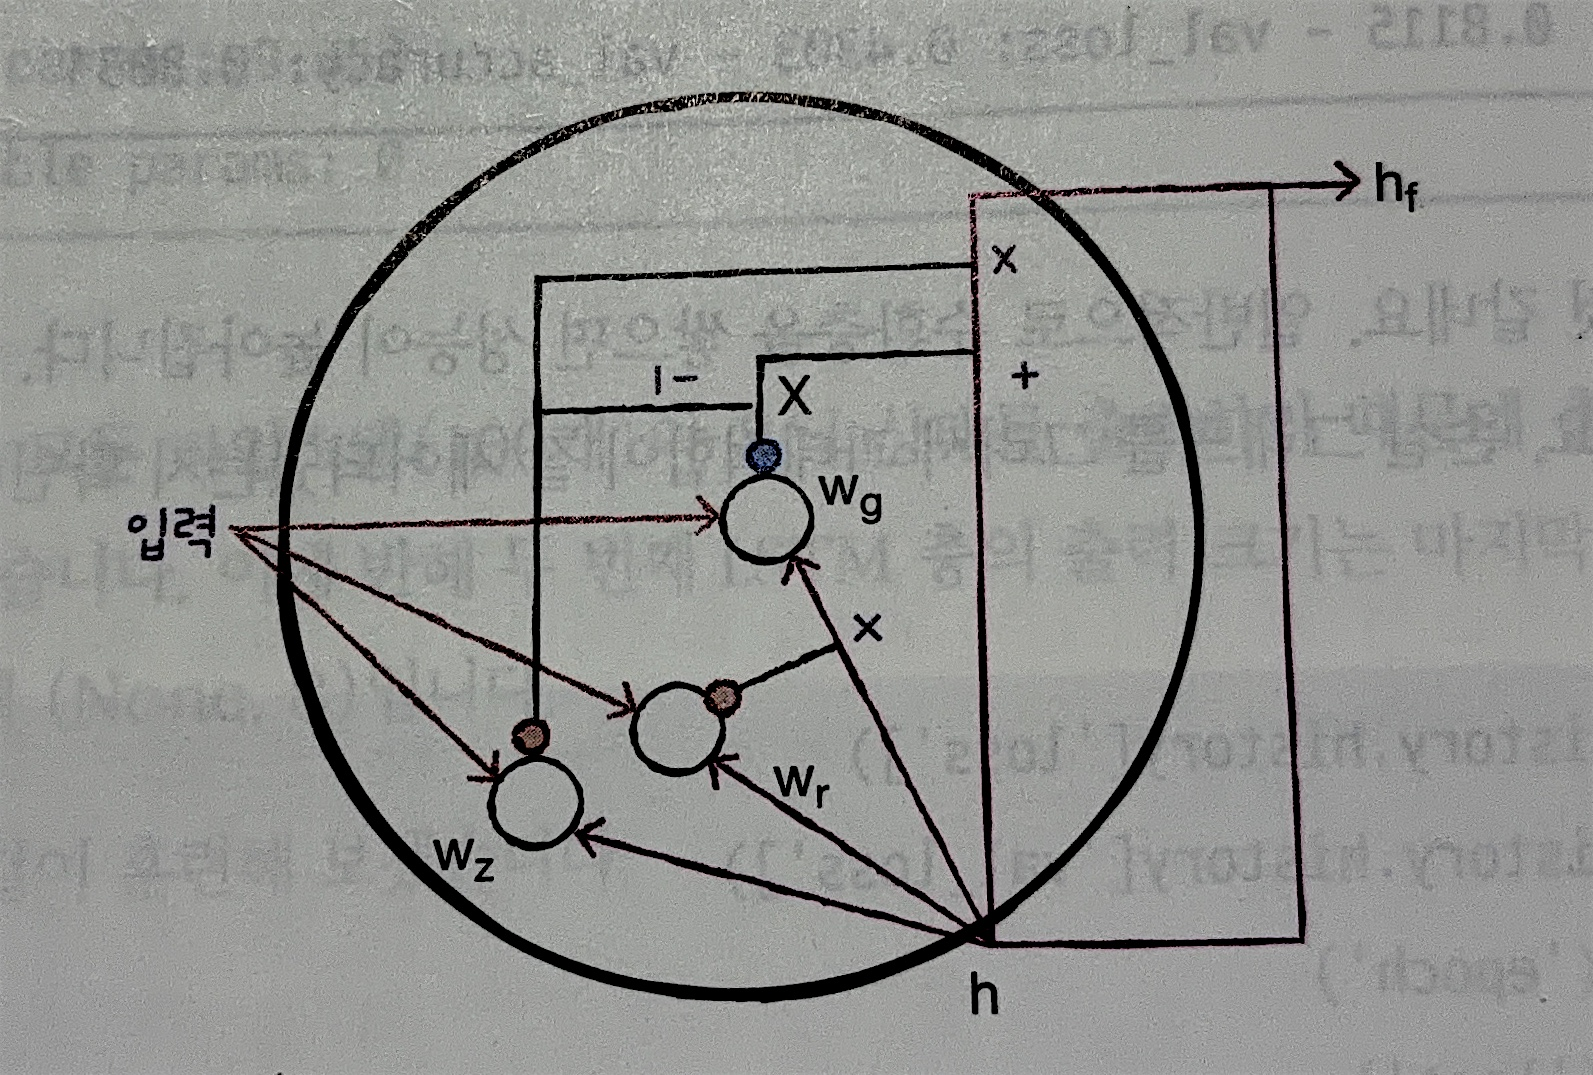
* GRU 셀에는 은닉 상태와 입력에 가중치를 곱하고 절편을 더하는 작은 셀이 3개 들어 있음. 2개는 시그모이드 활성화 함수를 사용하고 하나는 tanh 활성화 함수를 사용. 여기에서도 은닉 상태와 입력에 곱해지는 가중치를 합쳐서 나타냈음.
* 맨 왼쪽에서 $w_{z}$를 사용하는 셀의 출력이 은닉 상태에 바로 곱해져 삭제 게이트 역할을 수행. 이와 똑같은 출력을 1에서 뺀 다음에 가장 오른쪽 $w_{g}$를 사용하는 셀의 출력에 곱함. 이는 입력되는 정보를 제어하는 역할을 수행. 가운데 $w_{r}$을 사용하는 셀에서 출력된 값은 $w_{g}$ 셀이 사용할 은닉 상태의 정보를 제어.
* GRU 셀은 LSTM보다 가중치가 적기 때문에 계산량이 적지만 LSTM 못지 않은 좋은 성능을 내는 것으로 알려져 있음.

### GRU 신경망 훈련하기

In [ ]:
model4 = keras.Sequential()
model4.add(keras.layers.Embedding(500, 16, input_length=100))
model4.add(keras.layers.GRU(8))
model4.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
model4.summary()

* GRU 셀에는 3개의 작은 셀이 있음. 작은 셀에는 입력과 은닉 상태에 곱하는 가중치와 절편이 있음. 입력에 곱하는 가중치는 16 $\times$ 8 = 128개이고 은닉 상태에 곱하는 가중치는 8 $\times$ 8 = 64개. 그리고 절편은 뉴런마다 하나씩이므로 8개. 모두 더하면 128 + 64 + 8 = 200개. 이런 작은 셀이 3개이므로 모두 600개의 모델 파라미터가 필요. 그런데 summary() 메서드의 출력은 624개. 무엇이 잘못되었을까?
* 사실 텐서플로에 기본적으로 구현된 GRU 셀의 계산은 앞의 그림과 조금 다름. GRU 셀의 초기 버전은 다음 그림과 같이 계산됨.
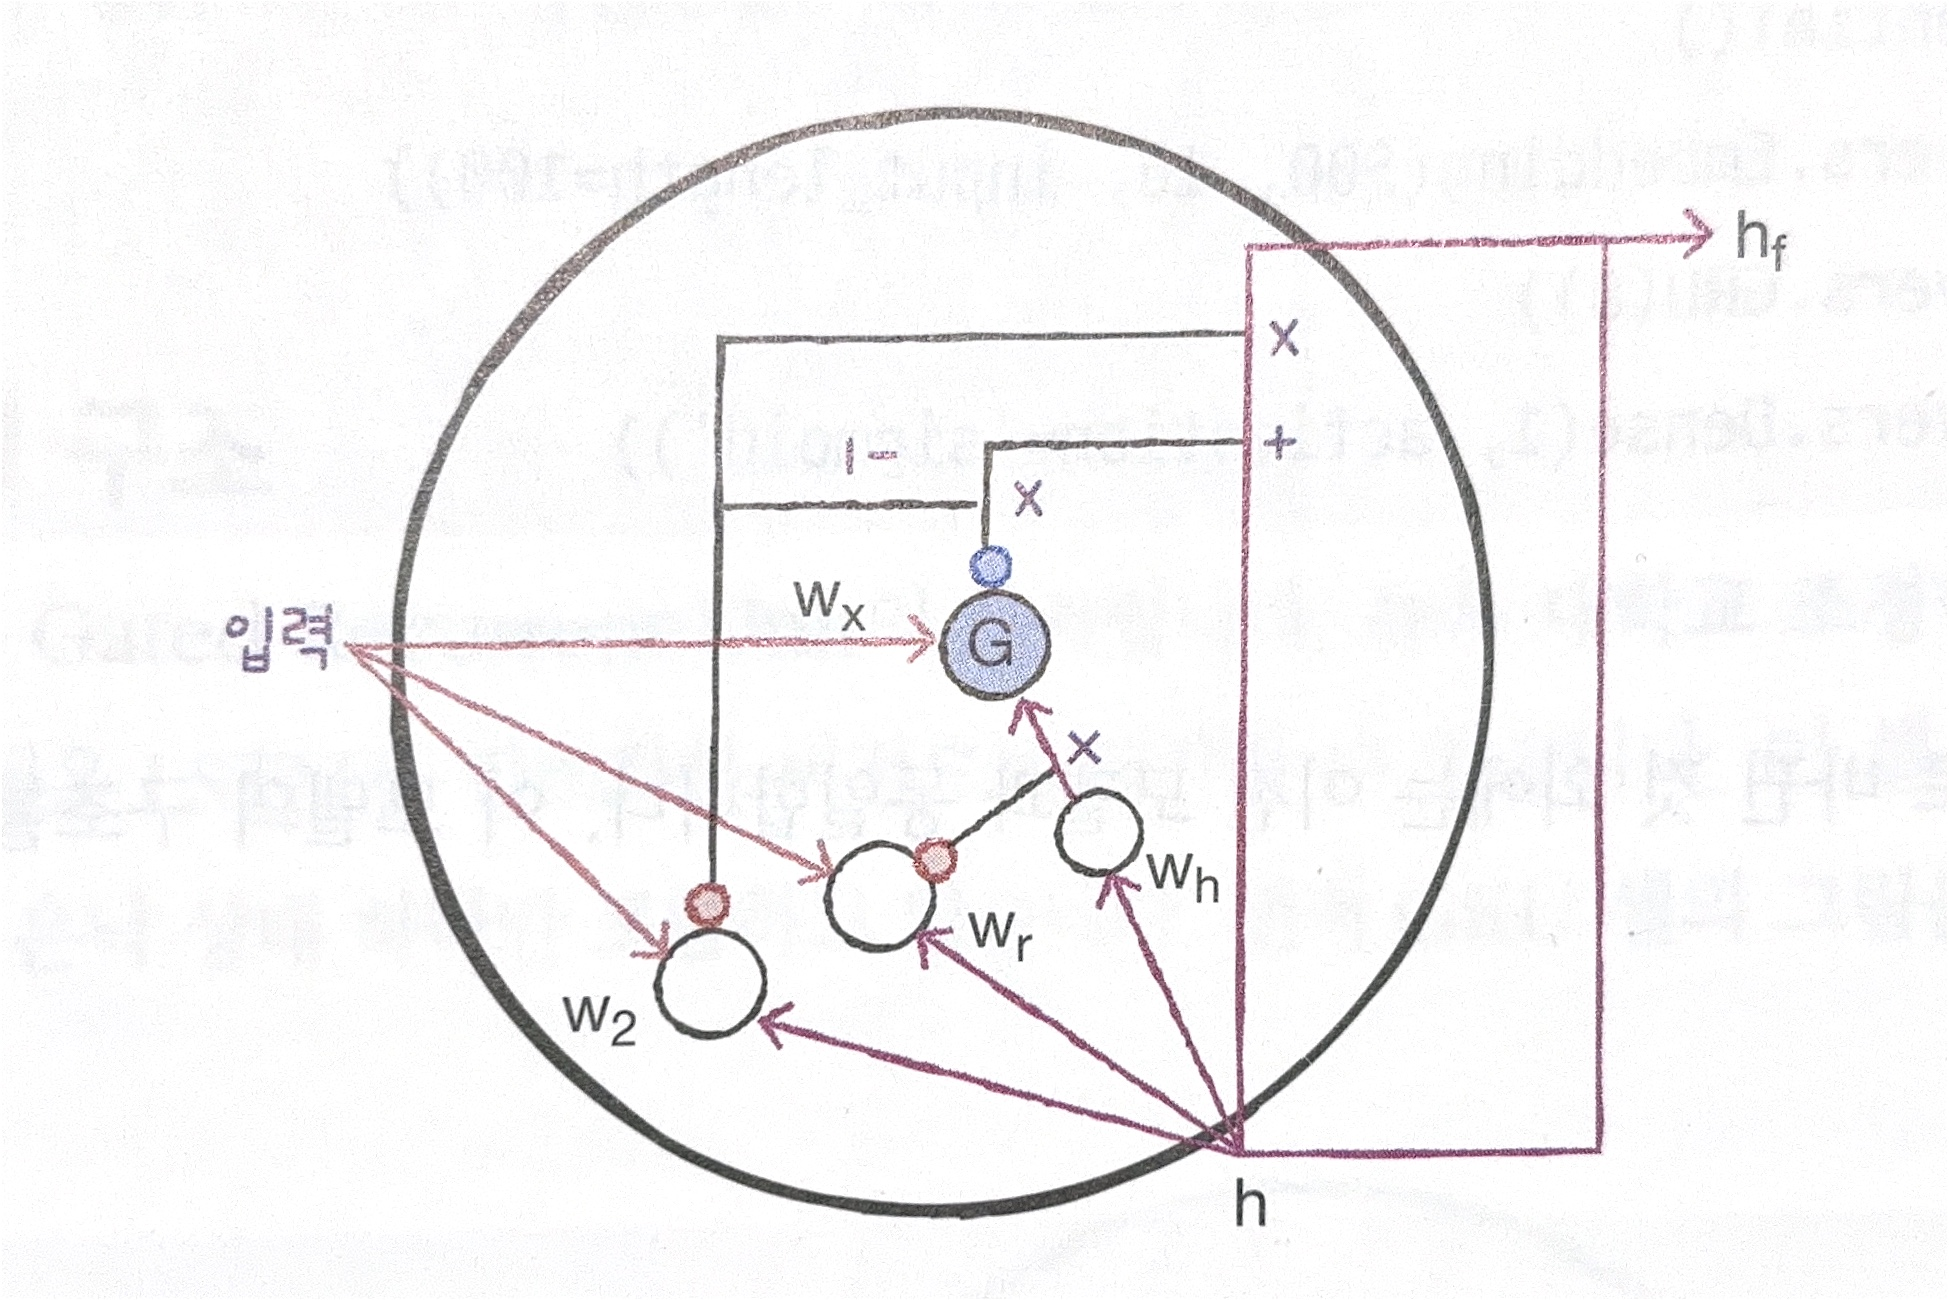
* 달라지는 부분은 G로 표시된 작은 셀에 들어가는 입력 부분. 이전에는 가운데 셀의 출력과 은닉 상태가 곱해진 후 G 셀에 입력되었음. 하지만 바뀐 그림에서는 은닉 상태가 먼저 가중치와 곱해진 다음 가운데 셀의 출력과 곱해짐. 그래서 이전에는 입력과 은닉 상태에 곱해지는 가중치를 $w_{g}$로 별도로 표기했는데 이 그림에서는 $w_{x}$와 $w_{h}$로 나누었음.
* 이렇게 나누어 계산하면 은닉 상태에 곱해지는 가중치 외에 절편이 별도로 필요. 따라서 작은 셀마다 하나씩 절편이 추가되고 8개의 뉴런이 있으므로 총 24개의 모델 파라미터가 더해짐. 따라서 GRU 층의 총 모델 파라미터 개수는 624개.
* 텐서플로가 이런 계산 방식을 사용하는 이유는 GPU를 잘 활용하기 위해서. 하지만 대부분 GRU 셀을 소개할 때는 전자의 그림을 사용. 널리 통용되는 이론과 구현이 차이 나는 경우가 종종 있음. 이로 인해 GRU 층의 모델 파라미터 개수를 혼동하지 말 것!

In [ ]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model4.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model4.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

* 출력 결과에서 볼 수 있듯이 LSTM와 거의 비슷한 성능을 냄.

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 드롭아웃을 사용하지 않았기 때문에 이전보다 훈련 손실과 검증 손실 사이에 차이가 있지만 훈련 과정이 잘 수렴되고 있는 것을 확인할 수 있음.